# Assignment 2: Python for Text Processing

**Submission deadline:** Friday, 31 Oct 2025, 11:55 PM  
**Assessment marks:** 35 marks (35% of the total unit assessment)

---

### Late Submission Penalty

Unless a Special Consideration request has been submitted and approved, a 5% penalty (of the total possible mark of the task) will be applied for each day a written report or presentation assessment is not submitted, up until the 7th day (including weekends). After the 7th day, a grade of ‘0’ will be awarded even if the assessment is submitted.

> **Example:** If the assignment is worth 8 marks (of the entire unit) and your submission is late by 19 hours (or 23 hours 59 minutes 59 seconds), 0.4 marks (5% of 8 marks) will be deducted. If your submission is late by 24 hours (or 47 hours 59 minutes 59 seconds), 0.8 marks (10% of 8 marks) will be deducted, and so on.

The submission time for all uploaded assessments is **11:55 PM**. A **1-hour grace period** is provided for technical concerns.  Apply for [Special Consideration](https://students.mq.edu.au/study/assessment-exams/special-consideration), if you think you should be granted an extended deadline or waive the late submission penalty. You should apply immediately when the situation occurs.

---

### Academic Integrity

All submitted work must be your own. For rules around AI tools, refer to **"Using Generative AI Tools" on iLearn**.

---

## Instructions

* Complete the five tasks below.

* Write your code and comments inside this notebook.

* Your notebook must include the running outputs of your final code.

* **Submit this `.ipynb` file, containing your code and outputs, to iLearn.**

---

### Assessment

-  Marks are based on the correctness of your code, outputs, and coding style.
-  A total of **2.5 marks** (0.5 per task) are awarded globally across the assignment for both of the below: (1) runnable codes; (2) good coding style: clean, modular code, meaningful variable names, and good comments.
-  If outputs are missing or incorrect, up to **25% of the marks for that task** can be deducted.
-  See each task below for the detailed mark breakdown.

---

### AI Tools Usage Policy


In this assignment, we view AI code generators such as copilot, CodeGPT, etc as tools that can help you write code quickly. You are allowed to use these tools, but with some conditions. To understand what you can and what you cannot do, please visit these information pages provided by Macquarie University.

- See: [Artificial Intelligence Tools and Academic Integrity in FSE](https://bit.ly/3uxgQP4)

If you choose to use these tools, make the following explicit in your submitted file as comments starting with "Use of AI generators in this assignment" :

- What part of your code is based on the output of such tools,
- What tools you used,
- What prompts you used to generate the code or text, and
- What modifications you made on the generated code or text?

This will help us assess your work fairly. 

**If we observe that you have used an AI generator and you do not give the above information, you may face disciplinary action.**





## Objectives of this assignment

In this assignment, you will work on the Quora Question Pairs (QQP) datset detailed below. The first two tasks will help you get familiar with the data, and the remaining requires you to implement deep neural networks.


**About the Quora Question Pairs (QQP) Dataset**

Description: A large dataset of 400k+ question pairs from Quora, labeled whether they are duplicates (semantically the same) or not. It features informal, noisy text with class imbalance, hard positives (low lexical overlap) and hard negatives (high overlap, different meaning). QQP is practically relevant for deduplicating FAQs, search, and support systems. Working on QQP builds transferable skills, such as text preprocessing, model comparison, threshold tuning, error analysis, and deployment-minded reasoning about real applications.

**Get familiar with the dataset**

In [4]:
! pip -q install datasets    
# Install the datasets package to access the dataset
# add the packages you used, and specify the verion you installed

You should consider upgrading via the 'C:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [134]:
from datasets import load_dataset
import numpy as np
import random

In [135]:
# 1) Load QQP
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"]
eval_ds  = ds["validation"]

q1_tr = list(train_ds["question1"])
q2_tr = list(train_ds["question2"])
y_tr  = np.array(train_ds["label"])

q1_te = list(eval_ds["question1"])
q2_te = list(eval_ds["question2"])
y_te  = np.array(eval_ds["label"])

Visualizing data

In [4]:
print(len(q1_tr),len(q1_te))
print(len(q2_tr),len(q2_te))
print(len(y_tr),len(y_te))

363846 40430
363846 40430
363846 40430


In [29]:
random_seed = 42
print(q1_tr[:3])
print(q2_tr[:3])
print(y_tr[:3])

['How is the life of a math student? Could you describe your own experiences?', 'How do I control my horny emotions?', 'What causes stool color to change to yellow?']
['Which level of prepration is enough for the exam jlpt5?', 'How do you control your horniness?', 'What can cause stool to come out as little balls?']
[0 1 0]


In [39]:
for i in range(5):
    x= random.randint(0,len(q1_tr))
    print("Q1 -- "+q1_tr[x] + "  Q2 --" + q2_tr[x] + " == " + str(y_tr[x]))

Q1 -- What can I do after my MBBs?  Q2 --What do i do after my MBBS ? == 1
Q1 -- What is Edgware like and how does the lifestyle compare to the London Borough of Ealing?  Q2 --What is ‘Edgware’ and how does the lifestyle compare to the London Borough of Brent? == 0
Q1 -- What does it mean when I dreamed of someone and said they're dying?  Q2 --What does it mean when I dream about somebody dying? == 0
Q1 -- I want to get a tattoo but I am scared of the pain. How do I overcome the fear?  Q2 --The pain from getting a tattoo relaxes me. Is there something wrong with me? == 0
Q1 -- What is the quantitative relationship between calorie loss and weight loss?  Q2 --Pepsi 500ml Contains only 250 calories. Why is it not allowed in a weight loss diet? == 0


### Task 1. What is the top-5 common NOUN in the question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 common NOUN in the questions. To find the part of speech, use NLTK's "Universal" tag set. You may need to use NLTK's `sent_tokenize` and `word_tokenize` to get words. The function returns a list that is descendingly sorted according to freqency, e.g. [(noun1, 22), (noun2, 10), ...].
<!-- To produce the correct results, the function must do this.  -->
Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use NLTK's part of speech tagger, using the "Universal" tagset.
- Use NLTK's `pos_tag_sents` instead of `pos_tag`.

Marking Criteria: 
- 2.5 marks for the correct codes and results of each column, namely question1 and question2 columns.




In [136]:
import nltk
nltk.download('universal_tagset')
nltk.download('punkt')
nltk.download('punkt_tab') 
nltk.download('averaged_perceptron_tagger_eng')

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag_sents

[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [8]:
# concatinating question 1 (from train and test)
q1 = q1_tr + q1_te
q2 = q2_tr + q2_te

# visualize
print(len(q1), len(q2))
q1[50:55]

404276 404276


['What are the best websites for entrepreneurs?',
 'What is the National nanotechnology initiative?',
 'Chown: invalid user: ‘ubuntu: ubuntu’?',
 'What are overlap lengths for columns, beam, slab etc?',
 'What type of government did Sparta have?']

In [9]:
q2[50:55]

['What are the best websites for entrepreneur?',
 'What is the lead time for SSN4EGS411 board?',
 'Do any popular Quorans gain financially through Quora?',
 'What is the length of rebars on beams between slabs?',
 'What types of government did Aristotle want?']

In [10]:
def top_five_nouns(q): #q -> list[strings]

    # concatinating all the questions into 1 string and converting into lowercase
    q = " ".join(q).lower()

    #using sentence tokenizer
    sentences = sent_tokenize(q) #returns a list[strings] (each string 1 sentence)

    #using word tokenizer 
    words = [word_tokenize(i) for i in sentences] #returns a list[list[strings]] strings-> words, list[strings] ->sentences

    # using pos_tag_sents to tag the words
    tagged = pos_tag_sents(words, tagset='universal') #returns list[list[tuple(word,tag)]]

    # Seperating nouns, and counting how manny times they appear 
    noun_count ={}
    for i in tagged:
        for j in i:
            if j[1] == 'NOUN':
                if j[0] not in noun_count:
                    noun_count[j[0]] = 1
                else:
                    noun_count[j[0]]+=1

    # sorting the words in descending order
    sorted_tagged_words = sorted(noun_count.items(), key = lambda x: x[1], reverse= True)

    # top 5 common
    top_5_common = sorted_tagged_words[:5]

    return top_5_common

In [11]:
print(top_five_nouns(q1))


[('i', 22283), ('people', 12739), ('india', 11816), ('way', 8524), ('life', 7521)]


In [12]:
print(top_five_nouns(q2))

[('i', 28490), ('people', 13628), ('india', 12430), ('way', 9536), ('life', 8066)]


### Task 2. What are the top-5 common stem 2-grams and non-stem 2-grams for question1 and question2, respectively? (5 marks)

Write codes that returns the top-5 most frequent 2-grams (bigrams) of stemmed and non-stemmed tokens along with their normalized frequency from the question1 and question2 columns of the QQP dataset. The output should be in descending order of frequency, **with frequencies normalized by the total number of bigrams (rounded to 4 decimal places)**, e.g., `[(('what', 'is'), 0.0105), (('what', 'are'), 0.0053), ...]`.

<!-- To produce the correct results, the function must do this: -->

Hint: The following steps will produce the correct results:

- Concatenate all questions together.
- Use NLTK's sentence tokeniser before NLTK's word tokeniser.
- Use the NLTK libraries to find the tokens and the stems.
- Use NLTK's Porter stemmer to get the root words.
- Round normalized frequency to 4 precision after the decimal point.
- When computing bigrams, do not consider words that are in different sentences. For example, if we have this text: `Sentence 1. And sentence 2.` the bigrams are: `('Sentence','1'), ('1','.'), ('.','And'), ('And','sentence')`, etc. Note that the following would not be a valid bigram, since the punctuation mark and the word "And" are in different sentences: `('.','And')`.

Marking Criteria: 
- 2.5 marks for the correct codes and restuls of each column, namely question1 and question2 columns.

In [13]:
from nltk.stem import PorterStemmer
from nltk import bigrams
stemmer = PorterStemmer()

In [14]:
# Write your code below
# concatinating question 1 (from train and test)
q1 = q1_tr + q1_te
q2 = q2_tr + q2_te

# visualize
print(len(q1), len(q2))

404276 404276


In [15]:
q1[45:50]

['What would happen if water disappeared from the earth?',
 'What was your weirdest childhood interest?',
 "What's the easiest way to learn Java programs?",
 '"Is ""rightness"" just a judgment of an observer or is it ever a property of an action?"',
 "Bihar assembly election 2015: why the NDA- led government was not successful in their approach. In future what things should they keep in mind so that they don't make the same mistake again?"]

In [16]:
q2[45:50]

['What would happen if ants disappeared from the Earth?',
 'Who are some artists with interesting or inspiring childhoods?',
 'What is the easiest way to learn java programming?',
 'Does the end justify the means?',
 'Will Narendra Modi win 400+ seat in L S 2019 ?']

In [17]:
def norm_freq(bgrm): #takes in list[list(tuples)] returns a dict with normalized freq
    #counting total number of bigrams
    total = 0
    for i in bgrm:
        total += len(i)

    bigram_count_dict = {} #dicitonary for counting bigrams

    for i in bgrm:
        for j in i:
            if j not in bigram_count_dict:
                bigram_count_dict[j] = 1
            else:
                bigram_count_dict[j] += 1
    
    # normalized by the total number of bigrams
    for k,v in bigram_count_dict.items():
        bigram_count_dict[k] = round(v/total,4) #rounding up to 4 decimal places

    return bigram_count_dict

# l =[[(1,2),(3,1)],[(2,5),(5,6)],[(1,2),(5,6)]]
# print(norm_freq(l))

    

In [18]:

def top_5_stem_and_non_stem_bigrams(q):
    # concatinating all the questions into 1 string and converting into lowercase
    q = " ".join(q).lower()

    #using sentence tokenizer
    sentences = sent_tokenize(q) #returns a list[strings] (each string 1 sentence)

    #using word tokenizer 
    words = [word_tokenize(i) for i in sentences] #returns a list[list[strings]] strings-> words, list[strings] ->sentences

    #bigrams of the non-stem tokens
    bgrm_non_stem = []
    bgrm_non_stem += [list(bigrams(i)) for i in words]

    #stems form the original tokens 
    stems = []
    for i in words:
        s =[stemmer.stem(j) for j in i]
        stems.append(s)

    #bigrams of the stem tokens
    bgrm_stem = []
    bgrm_stem += [list(bigrams(i)) for i in stems]

    #counting the frequencies
    bgrm_stem_freq = norm_freq(bgrm_stem)
    bgrm_non_stem_freq = norm_freq(bgrm_non_stem)

    # sorting the bigrams in descending order
    sorted_bigrams_stem = sorted(bgrm_stem_freq.items(), key = lambda x: x[1], reverse= True)
    sorted_bigrams_ns = sorted(bgrm_non_stem_freq.items(), key = lambda x: x[1], reverse= True)

    # top 5 common
    top_5_common_stem_bgrm = sorted_bigrams_stem[:5]
    top_5_common_non_stem_bgrm = sorted_bigrams_ns[:5]

    return top_5_common_non_stem_bgrm,top_5_common_stem_bgrm


In [ ]:
#for q1,
t1,t2 = top_5_stem_and_non_stem_bigrams(q1)
print(f"The top-5 most frequent 2-grams (bigrams) of stemmed are {t1} \n  and non-stemmed tokens are {t2} along with their normalized frequency from the question1")

The top-5 most frequent 2-grams (bigrams) of stemmed are [(('what', 'is'), 0.0129), (('is', 'the'), 0.0112), (('what', 'are'), 0.0102), (('how', 'do'), 0.0084), (('can', 'i'), 0.0066)]  and non-stemmed tokens are [(('what', 'is'), 0.0129), (('is', 'the'), 0.0112), (('what', 'are'), 0.0102), (('how', 'do'), 0.0084), (('can', 'i'), 0.0066)] along with their normalized frequency from the question1


In [ ]:
#for q2,
t1,t2 = top_5_stem_and_non_stem_bigrams(q2)
print(f"The top-5 most frequent 2-grams (bigrams) of stemmed are {t1} \n  and non-stemmed tokens are {t2} along with their normalized frequency from the question2")

The top-5 most frequent 2-grams (bigrams) of stemmed are [(('what', 'is'), 0.0123), (('is', 'the'), 0.0108), (('what', 'are'), 0.0098), (('how', 'do'), 0.0085), (('can', 'i'), 0.0068)] /n  and non-stemmed tokens are [(('what', 'is'), 0.0123), (('is', 'the'), 0.0108), (('what', 'are'), 0.0098), (('how', 'do'), 0.0085), (('can', 'i'), 0.0068)] along with their normalized frequency from the question2


### Task 3. Naïve Bayes Classifier (5.5 marks)

The QQR dataset contains pairs of questions with labels indicating whether the two questions are semantically duplicate (1) or not (0).

1. Using a Bag-of-Words representation, train a Naïve Bayes classifier to predict duplicates. (2 marks)

1. Report accuracy, precision, and recall on the test set. (1.5 marks)

1. Inspect your confusion matrix. Identify one type of error (false positive or false negative) that dominates. Suggest a possible reason for this pattern based on the dataset. (2 mark)

In [145]:
# From now on, you are allowed to use a subset of the dataset which requires less computing resources.
# Note that you have to use the same subset for the following coding tasks, which ensure fairness when comparing performance across different models.

Ntrain = 1000
Ntest = 100
ds = load_dataset("glue", "qqp")

# Use validation set as our test; optionally create a smaller train subset for speed
train_ds = ds["train"].select(range(Ntrain))
eval_ds  = ds["validation"].select(range(Ntest))

In [121]:
train_texts = [a + " [SEP] " + b for a, b in zip(train_ds["question1"], train_ds["question2"])]
eval_texts  = [a + " [SEP] " + b for a, b in zip(eval_ds["question1"], eval_ds["question2"])]

y_train = train_ds["label"]
y_eval  = eval_ds["label"]


In [123]:
train_texts[:5]

['How is the life of a math student? Could you describe your own experiences? [SEP] Which level of prepration is enough for the exam jlpt5?',
 'How do I control my horny emotions? [SEP] How do you control your horniness?',
 'What causes stool color to change to yellow? [SEP] What can cause stool to come out as little balls?',
 'What can one do after MBBS? [SEP] What do i do after my MBBS ?',
 'Where can I find a power outlet for my laptop at Melbourne Airport? [SEP] Would a second airport in Sydney, Australia be needed if a high-speed rail link was created between Melbourne and Sydney?']

In [126]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

# Learn the vocabulary from training data, then transform both sets
X_train = vectorizer.fit_transform(train_texts)
X_eval  = vectorizer.transform(eval_texts)

print(X_train.shape, X_eval.shape)


(1000, 3908) (100, 3908)


In [130]:
X_train

<1000x3908 sparse matrix of type '<class 'numpy.int64'>'
	with 16451 stored elements in Compressed Sparse Row format>

In [127]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)


MultinomialNB()

Accuracy:  0.660
Precision: 0.429
Recall:    0.400


<Figure size 600x500 with 0 Axes>

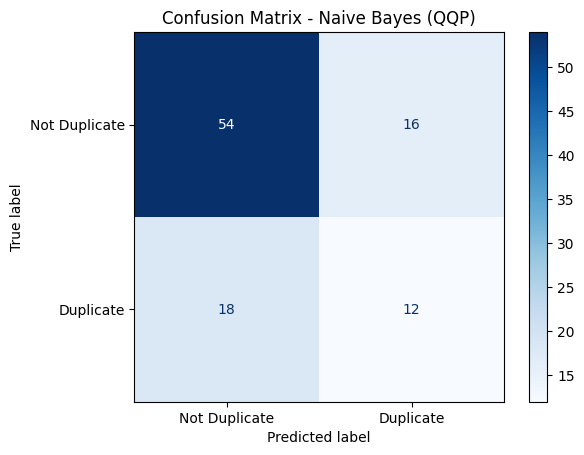

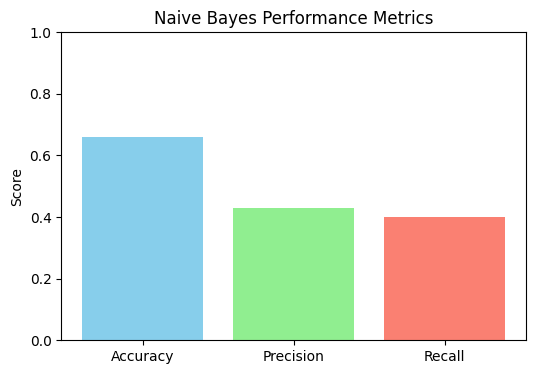

In [133]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = nb.predict(X_eval)

# 4️⃣ Compute metrics
acc = accuracy_score(y_eval, y_pred)
prec = precision_score(y_eval, y_pred)
rec = recall_score(y_eval, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

# 5️⃣ Plot confusion matrix
cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Duplicate", "Duplicate"])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Naive Bayes (QQP)")
plt.show()

# 6️⃣ (Optional) Plot metric comparison as a bar chart
metrics = ['Accuracy', 'Precision', 'Recall']
values = [acc, prec, rec]

plt.figure(figsize=(6,4))
plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)
plt.title("Naive Bayes Performance Metrics")
plt.ylabel("Score")
plt.show()


In [12]:
q1_tr = list(train_ds["question1"])
q2_tr = list(train_ds["question2"])
y_tr  = np.array(train_ds["label"])
idx_tr= np.array(train_ds["idx"])

q1_te = list(eval_ds["question1"])
q2_te = list(eval_ds["question2"])
y_te  = np.array(eval_ds["label"])
idx_te= np.array(eval_ds["idx"])

In [67]:
#word count in the full training set (q1 and q2)
q_tr = q1_tr + q2_tr
len(q_tr)

2000

In [110]:
print(type(q_tr))

<class 'list'>


In [71]:
# concatinating all the questions into 1 string and converting into lowercase
q_tr_str = " ".join(q_tr).lower()
q_tr_str[:120]


'how is the life of a math student? could you describe your own experiences? how do i control my horny emotions? what cau'

In [88]:
def tokenize(ds):
    # concatinating all the questions into 1 string and converting into lowercase
    ds_str = " ".join(ds).lower()

    #using sentence tokenizer
    sentences = sent_tokenize(ds_str) #returns a list[strings] (each string 1 sentence)

    #using word tokenizer 
    words = [word_tokenize(i) for i in sentences] #returns a list[list[strings]] strings-> words, list[strings] ->sentences

    return words


In [111]:
q_tr[:5]

['How is the life of a math student? Could you describe your own experiences?',
 'How do I control my horny emotions?',
 'What causes stool color to change to yellow?',
 'What can one do after MBBS?',
 'Where can I find a power outlet for my laptop at Melbourne Airport?']

In [89]:
all_words = tokenize(q_tr)

In [90]:
all_words[:5]

[['how', 'is', 'the', 'life', 'of', 'a', 'math', 'student', '?'],
 ['could', 'you', 'describe', 'your', 'own', 'experiences', '?'],
 ['how', 'do', 'i', 'control', 'my', 'horny', 'emotions', '?'],
 ['what', 'causes', 'stool', 'color', 'to', 'change', 'to', 'yellow', '?'],
 ['what', 'can', 'one', 'do', 'after', 'mbbs', '?']]

In [113]:
#creating vocabulary 
def vocabulary(q): #takes input list[strings]
    all_words = tokenize(q_tr)
    vocab = []
    for i in all_words:
        vocab+=i
    vocab = list(set(vocab))
    return vocab

In [120]:
vocab = vocabulary(q_tr)


In [117]:
len(x)

4040

In [119]:
my_list = ["a", "b", "c"]
new = [0]*len(my_list)
idx = my_list.index("b")
print(idx)
new[idx]+=1
print(new)

1
[0, 1, 0]


In [108]:
word_count_dict = {} #dicitonary for counting word occuernces in the whole dataset

for i in all_words:
    for j in i:
        if j not in word_count_dict :
            word_count_dict [j] = 1
        else:
            word_count_dict[j] += 1

print(word_count_dict)

{'how': 517, 'is': 719, 'the': 1009, 'life': 31, 'of': 450, 'a': 514, 'math': 11, 'student': 6, '?': 2118, 'could': 19, 'you': 231, 'describe': 2, 'your': 93, 'own': 9, 'experiences': 2, 'do': 410, 'i': 517, 'control': 9, 'my': 185, 'horny': 2, 'emotions': 1, 'what': 855, 'causes': 2, 'stool': 2, 'color': 1, 'to': 504, 'change': 15, 'yellow': 2, 'can': 287, 'one': 38, 'after': 31, 'mbbs': 6, 'where': 33, 'find': 19, 'power': 2, 'outlet': 1, 'for': 225, 'laptop': 6, 'at': 61, 'melbourne': 3, 'airport': 2, 'not': 56, 'feel': 24, 'guilty': 2, 'since': 5, 'am': 35, 'muslim': 1, 'and': 339, "'m": 9, 'conscious': 1, 'we': 56, 'wo': 2, "n't": 68, 'have': 104, 'sex': 19, 'together': 6, 'air': 15, 'traffic': 4, 'controlled': 1, 'best': 188, 'self': 6, 'help': 14, 'book': 14, 'read': 15, 'why': 206, 'did': 51, 'it': 202, 'enter': 1, 'university': 13, 'if': 115, 'achieve': 3, 'guaranteed': 1, 'marks': 11, 'in': 515, 'trinity': 1, 'college': 15, 'foundation': 3, 'need': 13, 'passport': 1, 'go': 19

In [102]:
q1_tokens = tokenize(q1_tr)
q1_tokens[:5]

[['how', 'is', 'the', 'life', 'of', 'a', 'math', 'student', '?'],
 ['could', 'you', 'describe', 'your', 'own', 'experiences', '?'],
 ['how', 'do', 'i', 'control', 'my', 'horny', 'emotions', '?'],
 ['what', 'causes', 'stool', 'color', 'to', 'change', 'to', 'yellow', '?'],
 ['what', 'can', 'one', 'do', 'after', 'mbbs', '?']]

In [107]:
dict1 = {'a': 1, 'b': 2}
dict2 = {'c': 3, 'd': 4}
combined_dict = dict1.copy() # Create a copy to avoid modifying dict1
for key, value in dict2.items():
    combined_dict[key] = value
print(combined_dict)

{'a': 1, 'b': 2, 'c': 3, 'd': 4}


In [ ]:
for i in range(len(q1_tr)):
    

{'could': 19, 'you': 231, 'describe': 2, 'your': 93, 'own': 9, 'experiences': 2, '?': 2118}


### Task 4. Siamese Neural Network (7 marks)

You now want to learn semantic similarity directly from the question pairs.

1. Design a Siamese Neural Network with two identical LSTM encoders that embed each question. (3 marks)

1. Use cosine similarity to classify duplicates, and report accuracy and F1-score. (2 marks)

1. Compare your Siamese model to your Naïve Bayes model. Which one handles imbalanced errors (precision vs. recall) better in your results, and why do you think that is? (2 marks)

In [137]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import BertTokenizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [138]:
# --- random seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [143]:
# --- parameters ---
MAX_LEN = 80
EMBED_SIZE = 256
LSTM_UNITS = 256
BATCH_SIZE = 32
N_EPOCHS = 2
LEARNING_RATE = 1e-3
MARGIN = 1.0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [144]:
# --- Tokenizer ---
TOKENIZER_NAME = "bert-base-uncased"
TOKENIZER = BertTokenizer.from_pretrained(TOKENIZER_NAME)
VOCAB_SIZE = TOKENIZER.vocab_size
PAD_TOKEN_ID = TOKENIZER.pad_token_id


In [139]:
# Write your code below
class QQPDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=32):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        q1 = self.df.iloc[idx]['question1']
        q2 = self.df.iloc[idx]['question2']
        label = self.df.iloc[idx]['label']

        q1_enc = self.tokenizer.encode_plus(
            q1, truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        q2_enc = self.tokenizer.encode_plus(
            q2, truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )

        return {
            'q1_input_ids': q1_enc['input_ids'].squeeze(),
            'q2_input_ids': q2_enc['input_ids'].squeeze(),
            'q1_attention_mask': q1_enc['attention_mask'].squeeze(),
            'q2_attention_mask': q2_enc['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.float)
        }



In [163]:
class SiameseNetwork(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, pad_idx):
        super(SiameseNetwork, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)

    def encode(self, x, mask):
        embedded = self.embedding(x)
        lengths = mask.sum(1).cpu()  # count of non-padding tokens per sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        output, (hidden, cell) = self.lstm(packed)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(hidden)

    def forward(self, q1, q1_mask, q2, q2_mask):  # ← updated to 4 arguments
        q1_embed = self.encode(q1, q1_mask)
        q2_embed = self.encode(q2, q2_mask)
        return q1_embed, q2_embed


In [164]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        cosine_sim = nn.functional.cosine_similarity(output1, output2)
        loss = torch.mean((1 - label) * torch.pow(cosine_sim, 2) +
                          label * torch.pow(torch.clamp(self.margin - cosine_sim, min=0.0), 2))
        return loss


In [165]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    
    for batch in loader:
        q1_ids = batch['q1_input_ids'].to(device)
        q2_ids = batch['q2_input_ids'].to(device)
        q1_mask = batch['q1_attention_mask'].to(device)
        q2_mask = batch['q2_attention_mask'].to(device)
        labels = batch['label'].float().to(device)

        optimizer.zero_grad()
        q1_embed, q2_embed = model(q1_ids, q1_mask, q2_ids, q2_mask)
        loss = criterion(q1_embed, q2_embed, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)


In [148]:
import pandas as pd

train_df = pd.DataFrame(train_ds)
eval_df   = pd.DataFrame(eval_ds)

print(train_df.head())


                                           question1  \
0  How is the life of a math student? Could you d...   
1                How do I control my horny emotions?   
2       What causes stool color to change to yellow?   
3                        What can one do after MBBS?   
4  Where can I find a power outlet for my laptop ...   

                                           question2  label  idx  
0  Which level of prepration is enough for the ex...      0    0  
1                 How do you control your horniness?      1    1  
2  What can cause stool to come out as little balls?      0    2  
3                       What do i do after my MBBS ?      1    3  
4  Would a second airport in Sydney, Australia be...      0    4  


In [150]:
train_dataset = QQPDataset(train_df, TOKENIZER, max_len=MAX_LEN)
val_dataset   = QQPDataset(eval_df, TOKENIZER, max_len=MAX_LEN)

In [151]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [166]:
siamese_model = SiameseNetwork(VOCAB_SIZE, EMBED_SIZE, LSTM_UNITS, PAD_TOKEN_ID).to(DEVICE)
criterion = ContrastiveLoss(margin=MARGIN).to(DEVICE)
optimizer = optim.Adam(siamese_model.parameters(), lr=LEARNING_RATE)


N_EPOCHS = 10

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(siamese_model, train_loader, optimizer, criterion, DEVICE)
    acc, f1 = evaluate(siamese_model, val_loader, DEVICE)
    print(f"Epoch {epoch+1}/{N_EPOCHS} | Loss: {train_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")


Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


TypeError: forward() missing 2 required positional arguments: 'q2' and 'q2_mask'

In [157]:
from sklearn.metrics import f1_score
import numpy as np
import torch

def find_best_threshold(model, loader, device):
    model.eval()
    sims, labels = [], []
    with torch.no_grad():
        for batch in loader:
            q1_ids = batch['q1_input_ids'].to(device)
            q2_ids = batch['q2_input_ids'].to(device)
            q1_mask = batch['q1_attention_mask'].to(device)
            q2_mask = batch['q2_attention_mask'].to(device)
            label = batch['label'].cpu().numpy()

            q1_embed, q2_embed = model(q1_ids, q1_mask, q2_ids, q2_mask)
            sim = torch.cosine_similarity(q1_embed, q2_embed).cpu().numpy()

            sims.extend(sim)
            labels.extend(label)

    sims, labels = np.array(sims), np.array(labels)
    best_t, best_f1 = 0, 0
    for t in np.linspace(0, 1, 50):
        preds = (sims > t).astype(int)
        f1 = f1_score(labels, preds)
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    return best_t, best_f1


In [158]:
best_t, best_f1 = find_best_threshold(siamese_model, val_loader, DEVICE)
print(f"Best threshold: {best_t:.2f}, F1: {best_f1:.4f}")


TypeError: forward() takes 3 positional arguments but 5 were given

### Task 5. Transformer-Based Classifier (10 marks)

Instead of handcrafted features or LSTMs, you now fine-tune a pre-trained Transformer (e.g., BERT or RoBERTa, etc) for QQP.

1. Fine-tune the model for 3 epochs with learning rate 2e-5. (3 marks)

1. Report the accuracy, precision, recall, and F1-score. (2 marks)

1. Compare your Transformer results with your Siamese model. Did the Transformer improve both precision and recall, or mainly one? What does this suggest about how it captures question meaning? (2 marks)

1. Look at one example your Transformer misclassified. Write a short explanation of why the model might have made this mistake. (3 marks)

In [ ]:
# Write your code below